In [1]:
from pathlib import Path
import sys

# Identify project root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Add project root to Python's module search path
sys.path.insert(0, str(PROJECT_ROOT))

# import utility function
from src.utils import describe_crs

# Provide input to describe CRS function
crs_4326 = describe_crs("EPSG:4326")
crs_32760 = describe_crs("EPSG:32760")

# print the results
print("EPSG:4326")
print("Units:", crs_4326["units"])
print("Datum:", crs_4326["datum"])

print("\nEPSG:32760")
print("Units:", crs_32760["units"])
print("Datum:", crs_32760["datum"])

CRS Name: WGS 84
EPSG Code: EPSG:4326
WKT: GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        MEMBER["World Geodetic System 1984 (G2296)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["geodetic longitude (Lon)",east,
            ORDER[2],
            ANGLEUNIT["degree",0.0174532925199433]

/Users/robmoore/geoanalytics/geog313-assignments/assignment-5/.pixi/envs/default/lib/python3.14/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


In [2]:
# build a fiji region polygon
from shapely.geometry import Polygon

# Fiji region coordinates (longitude, latitude)
coords = [
    (177.2, -16.1),
    (-178.3, -16.1),
    (-178.3, -19.2),
    (177.2, -19.2)
]

# create polygon
fiji_geom = Polygon(coords)

# calculate bounding box and area
print("Bounding box:", fiji_geom.bounds)
print("Area (square degrees):", fiji_geom.area)

Bounding box: (-178.3, -19.2, 177.2, -16.1)
Area (square degrees): 1102.0499999999993


In [3]:
from src.utils import shift_to360

# shuift Fiji polygon to 0-360 longitude convention
fiji_360 = shift_to360(fiji_geom)

# calculate bounding box
print("Original bounding box:", fiji_geom.bounds)
print("Shifted bounding box:", fiji_360.bounds)

# compare longitude widths
original_width = fiji_geom.bounds[2] - fiji_geom.bounds[0]
shifted_width = fiji_360.bounds[2] - fiji_360.bounds[0]

print("Original width:", original_width, "degrees")
print("Shifted width:", shifted_width, "degrees")

Original bounding box: (-178.3, -19.2, 177.2, -16.1)
Shifted bounding box: (177.2, -19.2, 181.7, -16.1)
Original width: 355.5 degrees
Shifted width: 4.5 degrees


In [4]:
# Import utility
from src.utils import reproject_geometry

# Define equal-area projection centered on Fiji
equal_area_crs = (
    "+proj=laea +lat_0=-17.5 +lon_0=180 "
    "+datum=WGS84 +units=m +no_defs"
)

# Reproject the corrected Fiji polygon
fiji_projected = reproject_geometry(
    fiji_360,
    "EPSG:4326",
    equal_area_crs
)

# Calculate area in square kilometers
area_km2 = fiji_projected.area / 1e6

print("Fiji region area:", round(area_km2, 2), "km2")

Fiji region area: 163784.55 km2


In [5]:
from shapely.geometry import box
from src.utils import utm_epsg

# build Taveuni AOI
aoi = box(179.85, -16.95, 179.99, -16.80)

# calculate centroid
centroid = aoi.centroid

lon = centroid.x
lat = centroid.y

print("Centroid longitude:", lon)
print("Centroid latitude:", lat)

# Determine UTM zone
zone, hemisphere, epsg = utm_epsg(lon, lat)

print("UTM Zone:", zone)
print("Hemisphere:", hemisphere)
print("EPSG:", epsg)

Centroid longitude: 179.92000000000002
Centroid latitude: -16.875
UTM Zone: 60
Hemisphere: south
EPSG: 32760


In [19]:
# compare to point across antimeridian
west_point = utm_epsg(179.9, -1)

# Point just east of the antimeridian
east_point = utm_epsg(-179.9, -1)

print("West of antimeridian:", west_point)
print("East of antimeridian:", east_point)

West of antimeridian: (60, 'south', 32760)
East of antimeridian: (1, 'south', 32701)


## Sentinel-2 scene, NDVI, and CRS report

The AOI is defined in EPSG:4326, while Sentinel-2 assets are stored in the scene's native projected CRS. The AOI must therefore be reprojected before clipping. The true AOI area is calculated in the equal-area CRS from Part 1, not in square degrees.

A common CRS mistake is clipping the EPSG:4326 AOI directly against a projected raster. That treats longitude and latitude as projected metre coordinates and can produce an empty or spatially incorrect result. `clip_asset` corrects this by transforming the AOI into the scene's `proj:code` before reading the COG window. The map uses a Plate Carrée projection centered at longitude 180 so Fiji remains continuous near the date line.

Scene id: S2B_1KAB_20230627_0_L2A
Date: 2023-06-27T22:20:44.322000+00:00
Cloud cover: 3.20267 %
Scene CRS: EPSG:32701
AOI true area: 247.639141 km2
AOI window read time: 58.276 seconds
Full red asset read time: 15.327 seconds
Full red asset shape: (1, 10980, 10980)
NDVI range: 0.0 to 1.0


/Users/robmoore/geoanalytics/geog313-assignments/assignment-5/.pixi/envs/default/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/robmoore/geoanalytics/geog313-assignments/assignment-5/.pixi/envs/default/lib/python3.14/site-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/robmoore/geoanalytics/geog313-assignments/assignment-5/.pixi/envs/default/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


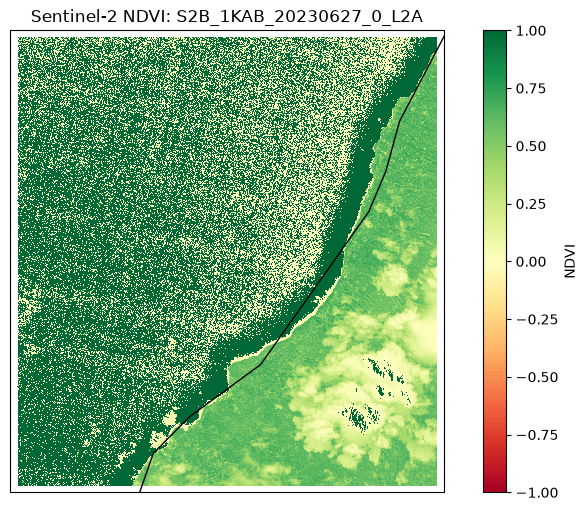

Wrote: /Users/robmoore/geoanalytics/geog313-assignments/assignment-5/results/ndvi.tif
Wrote: /Users/robmoore/geoanalytics/geog313-assignments/assignment-5/results/scene_metadata.json


In [6]:
import json
import os
import time

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import rasterio
from IPython.display import display

from src.utils import clip_asset, ndvi, search_best_scene

# Earth Search's public COGs are read anonymously from S3.
os.environ["AWS_NO_SIGN_REQUEST"] = "YES"
os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR"

# Search the AOI centroid for a recent low-cloud Sentinel-2 scene.
scene = search_best_scene(
    centroid,
    "2023-01-01/2026-10-08",
    max_cloud=10,
)
if scene is None:
    raise RuntimeError("No Sentinel-2 scene matched the search criteria")

scene_crs = scene.properties["proj:code"]
scene_date = scene.datetime.isoformat() if scene.datetime else scene.properties["datetime"]
cloud_cover = float(scene.properties["eo:cloud_cover"])
print("Scene id:", scene.id)
print("Date:", scene_date)
print("Cloud cover:", cloud_cover, "%")
print("Scene CRS:", scene_crs)

# Measure the AOI in the Part 1 equal-area CRS.
aoi_projected = reproject_geometry(aoi, "EPSG:4326", equal_area_crs)
aoi_area_km2 = aoi_projected.area / 1e6
print("AOI true area:", round(aoi_area_km2, 6), "km2")

# Read only the AOI windows from the red and near-infrared COG assets.
red_href = scene.assets["red"].href
window_start = time.perf_counter()
red = clip_asset(scene, "red", aoi)
nir = clip_asset(scene, "nir", aoi)
window_seconds = time.perf_counter() - window_start

# Benchmark the cost of reading the complete red asset for comparison only.
full_start = time.perf_counter()
with rasterio.open(red_href) as full_asset:
    full_data = full_asset.read()
    full_shape = full_data.shape
full_read_seconds = time.perf_counter() - full_start
print(f"AOI window read time: {window_seconds:.3f} seconds")
print(f"Full red asset read time: {full_read_seconds:.3f} seconds")
print("Full red asset shape:", full_shape)

ndvi_result = ndvi(red, nir).squeeze(drop=True)
print("NDVI range:", float(ndvi_result.min(skipna=True)), "to", float(ndvi_result.max(skipna=True)))

# Reproject only the clipped NDVI result for a date-line-centered Cartopy map.
ndvi_4326 = ndvi_result.rio.reproject("EPSG:4326")
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ndvi_4326.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    cbar_kwargs={"label": "NDVI"},
)
ax.coastlines()
ax.set_title(f"Sentinel-2 NDVI: {scene.id}")
plt.show()

# Export the clipped NDVI and scene metadata.
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
ndvi_result.rio.to_raster(results_dir / "ndvi.tif")
metadata = {
    "scene_id": scene.id,
    "date": scene_date,
    "cloud_cover": cloud_cover,
    "scene_crs": scene_crs,
    "aoi_area_km2": aoi_area_km2,
}
(results_dir / "scene_metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
print("Wrote:", results_dir / "ndvi.tif")
print("Wrote:", results_dir / "scene_metadata.json")